
# Triadic Cell Notebook v40
## Recursive transient-field runtime

This notebook continues from v39, but changes the viewpoint.

The branches do not "move."
The **matter field moves through them**.

So instead of thinking linearly in terms of branch motion, v40 treats the live branches as
fixed projections over a **shared recursive transient field**.

New ingredients:

- fixed branches from priors
- variable resoluteness of the same vacuum
- branch-specific gap masks
- **rival-error advantage** on the same requested slice
- **shared matter update** driven by weighted branch flux
- transient memory of previous advantage

The key shift is:

$$
\text{winner} \neq \text{largest absolute seat gain}
$$

It becomes:

$$
\text{winner} = \text{branch that explains the requested slice better than rivals}
$$

and that explanatory edge feeds a shared matter update.

Main outputs:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `transient_summary`
- `transient_trace_df`


In [1]:

from __future__ import annotations
import numpy as np, pandas as pd, matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)
print("Environment ready.")


Environment ready.


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [[0.95,0.15,0.10,0.20,0.30,0.10],[0.70,0.25,0.45,0.30,0.45,0.20],[0.55,0.20,0.60,0.25,0.70,0.35]],
    [[0.10,0.95,0.15,0.25,0.10,0.30],[0.25,0.72,0.25,0.50,0.25,0.45],[0.20,0.58,0.30,0.70,0.30,0.72]],
    [[0.20,0.10,0.95,0.15,0.25,0.12],[0.45,0.25,0.75,0.30,0.42,0.22],[0.62,0.22,0.55,0.25,0.72,0.30]],
    [[0.15,0.22,0.18,0.95,0.12,0.35],[0.28,0.42,0.25,0.75,0.22,0.58],[0.35,0.72,0.30,0.60,0.25,0.78]],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a, b):
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape, local_mold, alpha=0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape","bridge_value","declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936


In [3]:

raw_basis = np.array([
    [1.0,0.0,0.6,0.2,0.0,0.3],
    [0.2,1.0,0.0,0.6,0.2,0.0],
    [0.0,0.2,1.0,0.0,0.6,0.2],
    [0.6,0.0,0.2,1.0,0.0,0.6],
    [0.0,0.6,0.2,0.0,1.0,0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)

In [4]:

QUERY_MODES = ["existing","partial","noisy","ambiguous","inverse_hint"]
QUERY_WEIGHTS = np.array([0.28,0.28,0.18,0.16,0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls, mode):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.015, size=q.shape[0])
    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.45
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])
    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])
    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.56 * target + 0.44 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])
    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)


In [5]:

def directional_coeffs(x): return U @ x
def reconstruct_from_coeffs(c): return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query, target):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    return {
        "R": R, "M": M, "E": E,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
    }

def triadic_evaluate(query, cls):
    s0, _, _ = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = 0.35 * split["missing_ratio"] + 0.20 * split["excess_ratio"] + 0.45 * (1.0 - retrieve_fit)
    declaration_score = (
        0.60 * retrieve_fit + 0.35 * split["aligned_ratio"]
        - 0.95 * split["missing_ratio"] - 0.45 * split["excess_ratio"] - 0.45 * bridge_energy
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "declaration_score": float(declaration_score),
        "R": split["R"], "M": split["M"], "E": split["E"],
        "declared_value": projected2,
    }

def triadic_query(query):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def produce_fields_for_class(query, cls):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    retrieve_mask = normalize01(ev["R"])
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "declaration_score": ev["declaration_score"],
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"])


In [6]:

obs_dim = 3
OBS_W = np.array([
    [0.80,0.10,0.35,0.05,0.20,0.10],
    [0.10,0.75,0.10,0.30,0.05,0.25],
    [0.20,0.10,0.55,0.10,0.45,0.20],
], dtype=float)

def observable_from_declared(declared_value):
    return normalize01(OBS_W @ declared_value)

def build_inverse_vacuum(query, fields):
    inv_query = 1.0 - query
    contradiction = fields["contradiction_mask"]
    return normalize01(0.75 * inv_query + 0.25 * contradiction)

def apply_resoluteness(x, rho, eps=1e-8):
    return normalize01(np.clip(x, eps, 1.0) ** rho)

def branch_entropy_from_scores(scores):
    x = np.array(scores, dtype=float)
    z = x - np.max(x)
    e = np.exp(z)
    p = e / (np.sum(e) + 1e-8)
    return float(-np.sum(p * np.log(p + 1e-8)))

def build_gap_masks(pred_obs_by_cls):
    gap_masks = {}
    classes = list(pred_obs_by_cls.keys())
    for cls in classes:
        others = [pred_obs_by_cls[c] for c in classes if c != cls]
        if others:
            other_mean = np.mean(np.stack(others, axis=0), axis=0)
        else:
            other_mean = np.zeros_like(pred_obs_by_cls[cls])
        gap_masks[cls] = normalize01(np.abs(pred_obs_by_cls[cls] - other_mean))
    return gap_masks

def build_request_shape_gap(shared_matter, fields, gap_mask, rho=1.0, top_k=1):
    pred_obs = observable_from_declared(fields["declared_value"])
    vacuum = build_inverse_vacuum(shared_matter, fields)
    vacuum_obs = normalize01(OBS_W @ vacuum)

    vacuum_obs_r = apply_resoluteness(vacuum_obs, rho)
    need_obs_r = apply_resoluteness(1.0 - pred_obs, rho)
    gap_obs_r = apply_resoluteness(gap_mask, rho)

    request_scores = vacuum_obs_r * need_obs_r * (0.5 + 0.5 * gap_obs_r)
    idx = np.argsort(request_scores)[-top_k:]

    mask = np.zeros(obs_dim, dtype=float)
    mask[idx] = 1.0

    tol_lo, tol_hi = 0.08, 0.30
    t = min(max((rho - 0.35) / 1.10, 0.0), 1.0)
    tolerance = tol_hi * (1.0 - t) + tol_lo * t

    return {
        "mask": mask,
        "expected_profile": pred_obs,
        "vacuum_obs": vacuum_obs_r,
        "gap_obs": gap_obs_r,
        "tolerance": float(tolerance),
        "priority": float((vacuum_obs_r * (0.5 + 0.5 * gap_obs_r)).mean()),
        "rho": float(rho),
    }

def provider_pull(true_cls, request_shape):
    full_obs = observable_from_declared(chains[true_cls][2])
    mask = request_shape["mask"]
    packet = full_obs * mask + rng.normal(0.0, 0.02, size=full_obs.shape[0]) * mask
    return normalize01(packet)

def masked_error(obs_packet, pred_obs, mask):
    return float(np.mean(np.abs(mask * (obs_packet - pred_obs))))

def softmax_stable(x):
    z = x - np.max(x)
    e = np.exp(z)
    return e / (np.sum(e) + 1e-8)

DIRECT_THRESHOLD = 0.985
SHAPE_THRESHOLD = 0.78

def direct_lookup_score(query):
    scores = [(cls, cosine_similarity(query, chains[cls][0])) for cls in range(n_classes)]
    scores.sort(key=lambda x: x[1], reverse=True)
    cls, score = scores[0]
    return {"class": cls, "score": float(score), "hit": score >= DIRECT_THRESHOLD}

def shape_lookup_score(query):
    best, _, margin = triadic_query(query)
    return {"class": best["class"], "score": float(best["retrieve_fit"]), "margin": float(margin), "hit": best["retrieve_fit"] >= SHAPE_THRESHOLD}

def seat_gain(before_fields, after_fields):
    before_missing = float(before_fields["missing_mask"].mean())
    after_missing = float(after_fields["missing_mask"].mean())
    before_contra = float(before_fields["contradiction_mask"].mean())
    after_contra = float(after_fields["contradiction_mask"].mean())
    before_decl = float(before_fields["declaration_score"])
    after_decl = float(after_fields["declaration_score"])
    return float(0.60 * (before_missing - after_missing) - 0.25 * (after_contra - before_contra) + 0.15 * (after_decl - before_decl))

def rho_from_field(mean_seat_gain, mean_obs_misfit, winner_margin, entropy):
    raw = 4.0 * mean_seat_gain - 3.0 * mean_obs_misfit + 2.0 * winner_margin - 1.5 * entropy
    sig = 1.0 / (1.0 + np.exp(-raw))
    return float(0.35 + 1.10 * sig)


In [7]:

def v39_like_runtime(query, true_cls, cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)

    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]

    decl_sorted = sorted([(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)],
                         key=lambda x: x[1], reverse=True)[:beam_width]
    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score

    fixed_classes = [cls for cls, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]
    beam = {cls: query.copy() for cls in fixed_classes}
    rho = 1.0

    for _ in range(cycles):
        pred_obs_by_cls = {cls: observable_from_declared(produce_fields_for_class(beam[cls], cls)["declared_value"]) for cls in fixed_classes}
        gap_masks = build_gap_masks(pred_obs_by_cls)

        cycle_energies, cycle_seat_gains, cycle_misfits = [], [], []

        for cls in fixed_classes:
            q = beam[cls].copy()
            sg = 0.0
            last_obs_misfit = 0.0

            for _ in range(exhale_steps):
                f_before = produce_fields_for_class(q, cls)
                request = build_request_shape_gap(q, f_before, gap_masks[cls], rho=rho, top_k=1)
                packet = provider_pull(true_cls, request)
                pred_obs = observable_from_declared(f_before["declared_value"])
                last_obs_misfit = masked_error(packet, pred_obs, request["mask"])

                packet_back = normalize01(request["mask"] @ OBS_W)
                vacuum = build_inverse_vacuum(q, f_before)
                gap_back = normalize01(request["gap_obs"] @ OBS_W)
                vacuum_push = normalize01(0.45 * packet_back + 0.35 * apply_resoluteness(vacuum, rho) + 0.20 * gap_back)

                update = step_size * (0.6 * f_before["signed_correction"] + 0.4 * vacuum_push)
                q_new = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))
                f_after = produce_fields_for_class(q_new, cls)
                sg = seat_gain(f_before, f_after)
                q = q_new

            beam[cls] = q
            f_end = produce_fields_for_class(q, cls)
            energy = (
                0.80 * float(f_end["missing_mask"].mean())
                + 0.55 * float(f_end["contradiction_mask"].mean())
                - 0.75 * float(f_end["declaration_score"])
                - 0.25 * float(f_end["retrieve_mask"].mean())
                + 0.65 * last_obs_misfit
                - 0.45 * sg
            )
            cycle_energies.append((cls, float(energy)))
            cycle_seat_gains.append(float(sg))
            cycle_misfits.append(float(last_obs_misfit))

        cycle_energies = sorted(cycle_energies, key=lambda x: x[1])
        winner_margin = float(cycle_energies[1][1] - cycle_energies[0][1]) if len(cycle_energies) > 1 else 1.0
        entropy = branch_entropy_from_scores([-e for _, e in cycle_energies])
        rho = rho_from_field(float(np.mean(cycle_seat_gains)), float(np.mean(cycle_misfits)), winner_margin, entropy)

    final_scores = []
    for cls in fixed_classes:
        f = produce_fields_for_class(beam[cls], cls)
        energy = 0.80 * float(f["missing_mask"].mean()) + 0.55 * float(f["contradiction_mask"].mean()) - 0.75 * float(f["declaration_score"]) - 0.25 * float(f["retrieve_mask"].mean())
        final_scores.append((cls, float(energy)))
    final_cls = sorted(final_scores, key=lambda x: x[1])[0][0]
    final_fields = produce_fields_for_class(beam[final_cls], final_cls)
    return {"predicted_class": final_fields["predicted_class"], "fields": final_fields}


In [8]:

def v40_transient_runtime(query, true_cls, cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)

    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]

    decl_sorted = sorted([(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)],
                         key=lambda x: x[1], reverse=True)[:beam_width]
    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score

    fixed_classes = [cls for cls, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]

    matter = query.copy()
    rho = 1.0
    prev_adv = {cls: 0.0 for cls in fixed_classes}
    trace_rows = []
    last_cycle = None

    for cycle in range(cycles):
        # repeated local exhale into same shared matter field
        for _ in range(exhale_steps):
            fields_before = {cls: produce_fields_for_class(matter, cls) for cls in fixed_classes}
            pred_obs_by_cls = {cls: observable_from_declared(fields_before[cls]["declared_value"]) for cls in fixed_classes}
            gap_masks = build_gap_masks(pred_obs_by_cls)

            requests = {cls: build_request_shape_gap(matter, fields_before[cls], gap_masks[cls], rho=rho, top_k=1)
                        for cls in fixed_classes}
            packets = {cls: provider_pull(true_cls, requests[cls]) for cls in fixed_classes}

            # advantage: branch explains its own requested slice better than rivals do
            current_adv = {}
            for cls in fixed_classes:
                mask = requests[cls]["mask"]
                obs = packets[cls]
                self_err = masked_error(obs, pred_obs_by_cls[cls], mask)
                rival_errs = [masked_error(obs, pred_obs_by_cls[r], mask) for r in fixed_classes if r != cls]
                if rival_errs:
                    advantage = float(np.mean(rival_errs) - self_err)
                else:
                    advantage = 0.0
                current_adv[cls] = advantage

            transient_adv = {cls: 0.65 * current_adv[cls] + 0.35 * prev_adv[cls] for cls in fixed_classes}
            weights = softmax_stable(np.array([transient_adv[cls] for cls in fixed_classes]))
            weight_map = {cls: float(w) for cls, w in zip(fixed_classes, weights)}

            total_flux = np.zeros_like(matter)
            seat_gains_local = []
            misfits_local = []

            for cls in fixed_classes:
                f_before = fields_before[cls]
                packet_back = normalize01(requests[cls]["mask"] @ OBS_W)
                gap_back = normalize01(requests[cls]["gap_obs"] @ OBS_W)
                vacuum = build_inverse_vacuum(matter, f_before)
                vacuum_push = normalize01(
                    0.35 * packet_back
                    + 0.35 * apply_resoluteness(vacuum, rho)
                    + 0.30 * gap_back
                )
                branch_flux = normalize01(0.6 * f_before["signed_correction"] + 0.4 * vacuum_push)
                total_flux = total_flux + weight_map[cls] * branch_flux
                misfits_local.append(masked_error(packets[cls], pred_obs_by_cls[cls], requests[cls]["mask"]))

            matter_new = normalize01(damping * matter + (1.0 - damping) * normalize01(matter + step_size * total_flux))
            fields_after = {cls: produce_fields_for_class(matter_new, cls) for cls in fixed_classes}

            for cls in fixed_classes:
                seat_gains_local.append(seat_gain(fields_before[cls], fields_after[cls]))

            matter = matter_new
            prev_adv = transient_adv

        # score after cycle on updated shared matter
        fields_now = {cls: produce_fields_for_class(matter, cls) for cls in fixed_classes}
        pred_obs_by_cls = {cls: observable_from_declared(fields_now[cls]["declared_value"]) for cls in fixed_classes}
        gap_masks = build_gap_masks(pred_obs_by_cls)
        requests = {cls: build_request_shape_gap(matter, fields_now[cls], gap_masks[cls], rho=rho, top_k=1)
                    for cls in fixed_classes}
        packets = {cls: provider_pull(true_cls, requests[cls]) for cls in fixed_classes}

        cycle_info = []
        misfits_cycle = []
        for cls in fixed_classes:
            mask = requests[cls]["mask"]
            obs = packets[cls]
            self_err = masked_error(obs, pred_obs_by_cls[cls], mask)
            rival_errs = [masked_error(obs, pred_obs_by_cls[r], mask) for r in fixed_classes if r != cls]
            advantage = float(np.mean(rival_errs) - self_err) if rival_errs else 0.0
            transient = float(0.65 * advantage + 0.35 * prev_adv[cls])

            f_now = fields_now[cls]
            energy = (
                0.78 * float(f_now["missing_mask"].mean())
                + 0.55 * float(f_now["contradiction_mask"].mean())
                - 0.75 * float(f_now["declaration_score"])
                - 0.25 * float(f_now["retrieve_mask"].mean())
                + 0.55 * self_err
                - 0.50 * transient
            )

            cycle_info.append({
                "cls": cls,
                "fields": f_now,
                "request": requests[cls],
                "self_err": float(self_err),
                "advantage": float(advantage),
                "transient_advantage": float(transient),
                "energy": float(energy),
            })
            misfits_cycle.append(float(self_err))

        ranked = sorted(cycle_info, key=lambda x: x["energy"])
        winner_margin = float(ranked[1]["energy"] - ranked[0]["energy"]) if len(ranked) > 1 else 1.0
        entropy = branch_entropy_from_scores([-x["energy"] for x in ranked])

        mean_seat_gain = float(np.mean(seat_gains_local)) if seat_gains_local else 0.0
        mean_obs_misfit = float(np.mean(misfits_cycle)) if misfits_cycle else 0.0
        rho = rho_from_field(mean_seat_gain, mean_obs_misfit, winner_margin, entropy)

        for item in cycle_info:
            f = item["fields"]
            r = item["request"]
            trace_rows.append({
                "cycle": cycle,
                "class": item["cls"],
                "rho": float(rho),
                "energy": float(item["energy"]),
                "advantage": float(item["advantage"]),
                "transient_advantage": float(item["transient_advantage"]),
                "self_err": float(item["self_err"]),
                "missing_mass": float(f["missing_mask"].mean()),
                "retrieve_mass": float(f["retrieve_mask"].mean()),
                "contradiction_mass": float(f["contradiction_mask"].mean()),
                "declaration_score": float(f["declaration_score"]),
                "request_mask_0": float(r["mask"][0]),
                "request_mask_1": float(r["mask"][1]),
                "request_mask_2": float(r["mask"][2]),
                "gap_obs_0": float(r["gap_obs"][0]),
                "gap_obs_1": float(r["gap_obs"][1]),
                "gap_obs_2": float(r["gap_obs"][2]),
                "vacuum_obs_0": float(r["vacuum_obs"][0]),
                "vacuum_obs_1": float(r["vacuum_obs"][1]),
                "vacuum_obs_2": float(r["vacuum_obs"][2]),
                "tolerance": float(r["tolerance"]),
            })

        last_cycle = ranked

    final_cls = last_cycle[0]["cls"]
    final_fields = produce_fields_for_class(matter, final_cls)
    return {
        "predicted_class": final_fields["predicted_class"],
        "fields": final_fields,
        "trace_df": pd.DataFrame(trace_rows),
        "fixed_classes": fixed_classes,
        "final_matter": matter,
    }


In [9]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

v39 = v39_like_runtime(q0, true_cls=example_cls)
v40 = v40_transient_runtime(q0, true_cls=example_cls)
transient_trace_df = v40["trace_df"]

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "v39_predicted_class": v39["predicted_class"],
    "v40_predicted_class": v40["predicted_class"],
    "v39_missing_mass": float(v39["fields"]["missing_mask"].mean()),
    "v40_missing_mass": float(v40["fields"]["missing_mask"].mean()),
    "v39_retrieve_mass": float(v39["fields"]["retrieve_mask"].mean()),
    "v40_retrieve_mass": float(v40["fields"]["retrieve_mask"].mean()),
    "fixed_classes": str(v40["fixed_classes"]),
}])
single_example


,true_class,query_mode,v39_predicted_class,v40_predicted_class,v39_missing_mass,v40_missing_mass,v39_retrieve_mass,v40_retrieve_mass,fixed_classes
0,1,partial,3,3,0.339721,0.402304,0.660279,0.597696,"[3, 2, 0]"


In [10]:

transient_trace_df.head(12)


,cycle,class,rho,energy,advantage,transient_advantage,self_err,missing_mass,retrieve_mass,contradiction_mass,...,request_mask_0,request_mask_1,request_mask_2,gap_obs_0,gap_obs_1,gap_obs_2,vacuum_obs_0,vacuum_obs_1,vacuum_obs_2,tolerance
0,0,3,0.662259,0.199784,0.099504,0.096100,0.025363,0.523510,0.476490,0.025242,...,1.0,0.0,0.0,0.298511,0.378945,0.225187,1.000000,0.994145,1.000000,0.170000
1,0,2,0.662259,0.627250,-0.066737,-0.064522,0.145515,0.486413,0.513587,0.092954,...,0.0,1.0,0.0,0.088353,0.200210,0.179899,1.000000,1.000000,1.000000,0.170000
2,0,0,0.662259,0.893685,-0.059578,-0.056604,0.135560,0.691271,0.308729,0.132384,...,0.0,1.0,0.0,0.210159,0.178735,0.045288,1.000000,1.000000,1.000000,0.170000
3,1,3,0.635876,0.105259,0.094656,0.095280,0.034753,0.485096,0.514904,0.030274,...,1.0,0.0,0.0,0.434434,0.522444,0.362648,0.988723,0.968413,0.991783,0.237548
4,1,2,0.635876,0.495334,-0.062975,-0.063606,0.145919,0.436495,0.563505,0.101761,...,0.0,1.0,0.0,0.197549,0.331677,0.315549,0.995850,0.984826,1.000000,0.237548
5,1,0,0.635876,0.671858,-0.062087,-0.061125,0.148898,0.565881,0.434119,0.139538,...,0.0,1.0,0.0,0.341659,0.328572,0.120512,1.000000,0.992083,1.000000,0.237548
6,2,3,0.629429,0.020207,0.091255,0.092128,0.032857,0.444328,0.555672,0.037594,...,1.0,0.0,0.0,0.438777,0.532532,0.369524,0.963208,0.944548,0.969956,0.242825
7,2,2,0.629429,0.397805,-0.059235,-0.060181,0.136530,0.409347,0.590653,0.109890,...,0.0,1.0,0.0,0.217705,0.333351,0.327242,0.969406,0.961454,0.983333,0.242825
8,2,0,0.629429,0.466197,-0.064508,-0.063828,0.141003,0.448416,0.551584,0.146102,...,0.0,1.0,0.0,0.339439,0.351927,0.121519,0.979611,0.967686,0.998309,0.242825
9,3,3,0.613182,-0.039636,0.089082,0.089681,0.030403,0.402304,0.597696,0.056041,...,1.0,0.0,0.0,0.435794,0.529272,0.367474,0.944784,0.922911,0.953211,0.244114


In [11]:

rows_compare = []
for true_cls in range(n_classes):
    for _ in range(350):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(true_cls, mode)

        first = produce_fields_best(q)
        v39 = v39_like_runtime(q, true_cls=true_cls)
        v40 = v40_transient_runtime(q, true_cls=true_cls)

        rows_compare.append({
            "true_class": true_cls,
            "query_mode": mode,
            "first_correct": int(first["predicted_class"] == true_cls),
            "v39_correct": int(v39["predicted_class"] == true_cls),
            "v40_correct": int(v40["predicted_class"] == true_cls),
            "first_missing_mass": float(first["missing_mask"].mean()),
            "v39_missing_mass": float(v39["fields"]["missing_mask"].mean()),
            "v40_missing_mass": float(v40["fields"]["missing_mask"].mean()),
            "first_retrieve_mass": float(first["retrieve_mask"].mean()),
            "v39_retrieve_mass": float(v39["fields"]["retrieve_mask"].mean()),
            "v40_retrieve_mass": float(v40["fields"]["retrieve_mask"].mean()),
        })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,v39_correct,v40_correct,first_missing_mass,v39_missing_mass,v40_missing_mass,first_retrieve_mass,v39_retrieve_mass,v40_retrieve_mass
0,0,existing,1,1,1,0.047715,0.000000,0.012206,0.952285,1.000000,0.987794
1,0,noisy,1,1,1,0.438561,0.140503,0.051513,0.561439,0.859497,0.948487
2,0,existing,1,1,1,0.032296,0.000000,0.013653,0.967704,1.000000,0.986347
3,0,noisy,1,1,1,0.080009,0.000000,0.000000,0.919990,1.000000,1.000000
4,0,inverse_hint,1,1,1,0.269007,0.241844,0.251096,0.730993,0.758156,0.748904


In [12]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "v39_accuracy": float(compare_df["v39_correct"].mean()),
    "v40_accuracy": float(compare_df["v40_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "v39_missing_mass": float(compare_df["v39_missing_mass"].mean()),
    "v40_missing_mass": float(compare_df["v40_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,v39_accuracy,v40_accuracy,first_pass_missing_mass,v39_missing_mass,v40_missing_mass
0,0.830714,0.817857,0.83,0.297178,0.113173,0.128898


In [13]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct","v39_correct","v40_correct",
        "first_missing_mass","v39_missing_mass","v40_missing_mass",
        "first_retrieve_mass","v39_retrieve_mass","v40_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)
by_mode_compare["v40_vs_first_gain"] = by_mode_compare["v40_correct"] - by_mode_compare["first_correct"]
by_mode_compare["v40_vs_v39_gain"] = by_mode_compare["v40_correct"] - by_mode_compare["v39_correct"]
by_mode_compare["v40_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["v40_missing_mass"]
by_mode_compare = by_mode_compare.sort_values("v40_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,v39_correct,v40_correct,first_missing_mass,v39_missing_mass,v40_missing_mass,first_retrieve_mass,v39_retrieve_mass,v40_retrieve_mass,v40_vs_first_gain,v40_vs_v39_gain,v40_missing_drop
4,partial,0.565116,0.562791,0.574419,0.561673,0.217507,0.234827,0.437939,0.779392,0.763623,0.009302,0.011628,0.326847
3,noisy,1.000000,1.000000,1.000000,0.189084,0.061000,0.060039,0.810222,0.930666,0.927461,0.000000,0.000000,0.129044
1,existing,1.000000,1.000000,1.000000,0.068196,0.006527,0.010968,0.925428,0.952489,0.945772,0.000000,0.000000,0.057229
2,inverse_hint,0.734694,0.714286,0.721088,0.273097,0.135994,0.158872,0.714432,0.832260,0.809382,-0.013605,0.006803,0.114225
0,ambiguous,0.949309,0.884793,0.935484,0.295137,0.128542,0.173749,0.697183,0.842272,0.797065,-0.013825,0.050691,0.121388


In [14]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()
partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_v39_accuracy": float(partial_df["v39_correct"].mean()),
    "partial_v40_accuracy": float(partial_df["v40_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_v39_missing_mass": float(partial_df["v39_missing_mass"].mean()),
    "partial_v40_missing_mass": float(partial_df["v40_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_v39_retrieve_mass": float(partial_df["v39_retrieve_mass"].mean()),
    "partial_v40_retrieve_mass": float(partial_df["v40_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_v39_accuracy,partial_v40_accuracy,partial_first_missing_mass,partial_v39_missing_mass,partial_v40_missing_mass,partial_first_retrieve_mass,partial_v39_retrieve_mass,partial_v40_retrieve_mass
0,0.565116,0.562791,0.574419,0.561673,0.217507,0.234827,0.437939,0.779392,0.763623


In [15]:

transient_summary = pd.DataFrame([{
    "mean_rho": float(transient_trace_df["rho"].mean()) if len(transient_trace_df) else np.nan,
    "mean_advantage": float(transient_trace_df["advantage"].mean()) if len(transient_trace_df) else np.nan,
    "mean_transient_advantage": float(transient_trace_df["transient_advantage"].mean()) if len(transient_trace_df) else np.nan,
    "mean_self_err": float(transient_trace_df["self_err"].mean()) if len(transient_trace_df) else np.nan,
    "mean_tolerance": float(transient_trace_df["tolerance"].mean()) if len(transient_trace_df) else np.nan,
    "mean_gap_obs_0": float(transient_trace_df["gap_obs_0"].mean()) if len(transient_trace_df) else np.nan,
    "mean_gap_obs_1": float(transient_trace_df["gap_obs_1"].mean()) if len(transient_trace_df) else np.nan,
    "mean_gap_obs_2": float(transient_trace_df["gap_obs_2"].mean()) if len(transient_trace_df) else np.nan,
}])
transient_summary


,mean_rho,mean_advantage,mean_transient_advantage,mean_self_err,mean_tolerance,mean_gap_obs_0,mean_gap_obs_1,mean_gap_obs_2
0,0.635186,-0.010161,-0.009881,0.105159,0.223622,0.296696,0.364318,0.240151


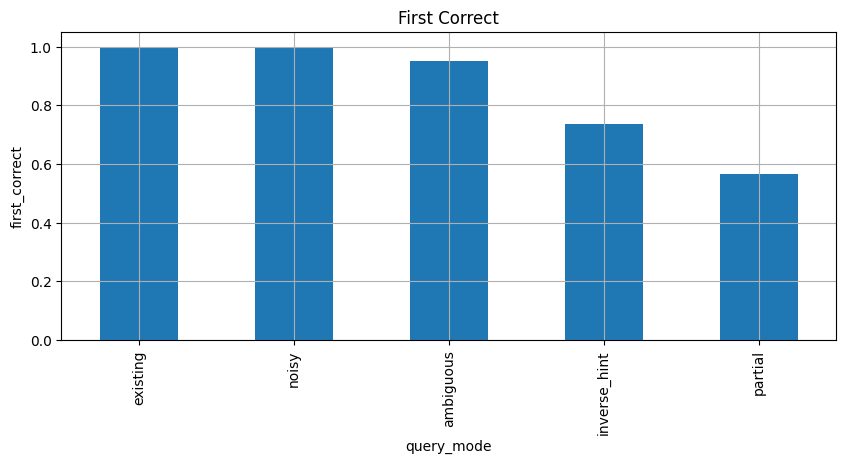

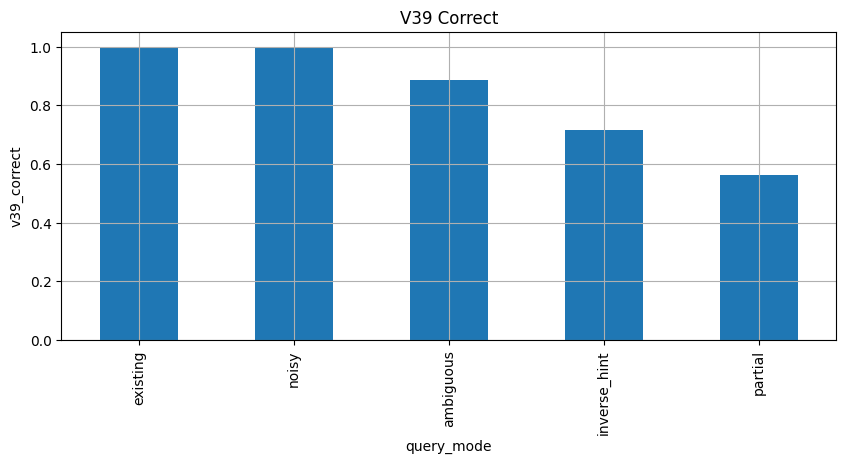

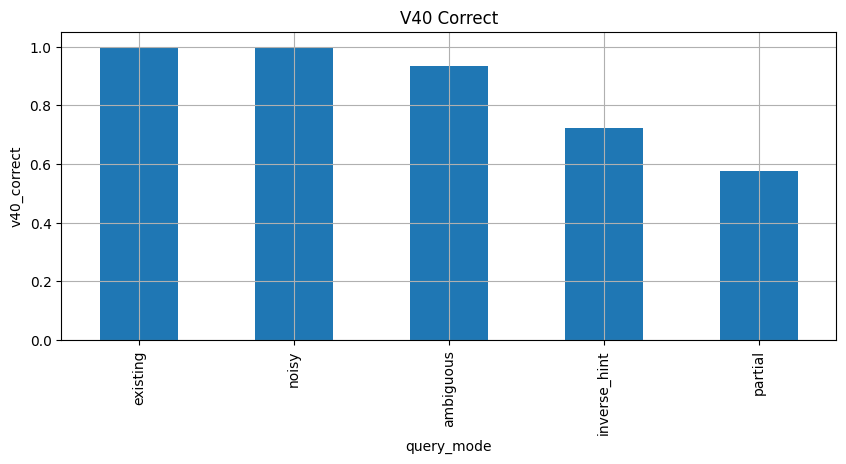

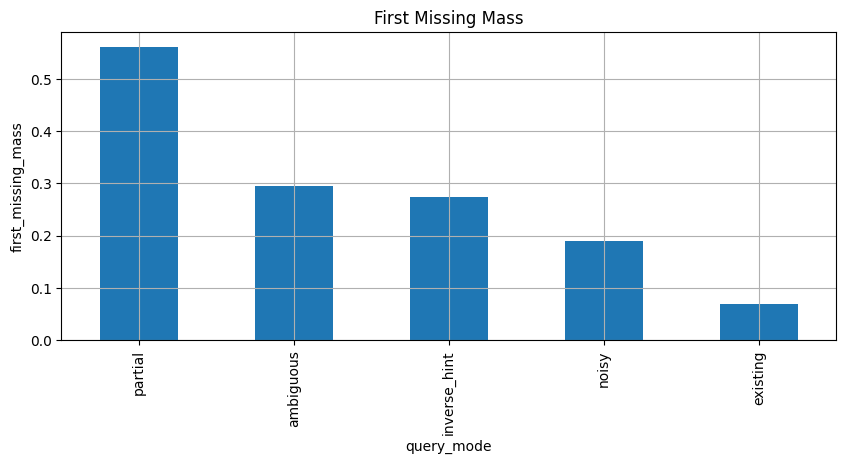

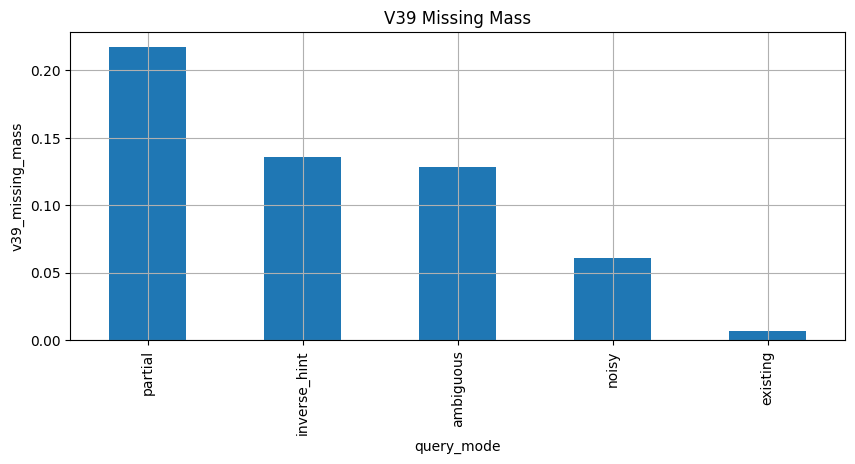

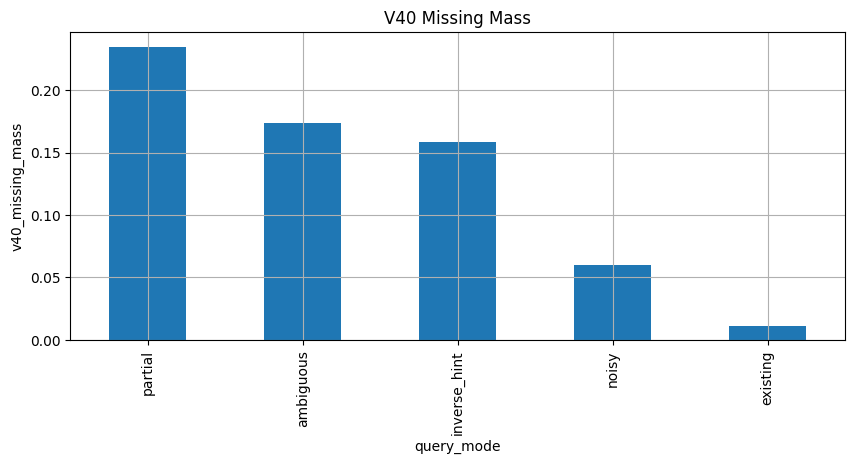

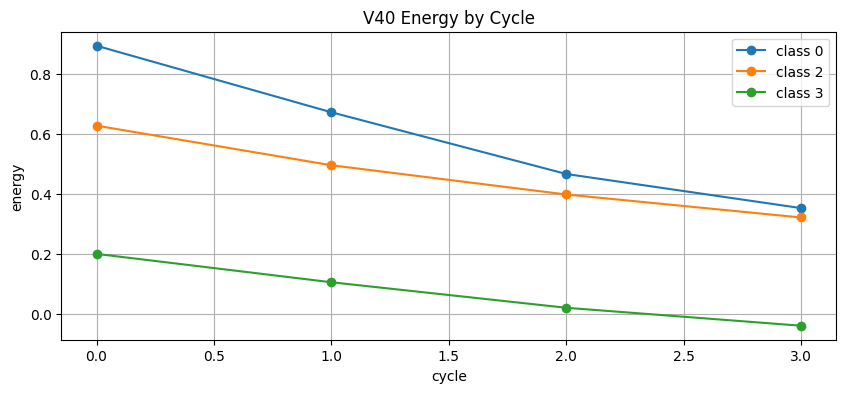

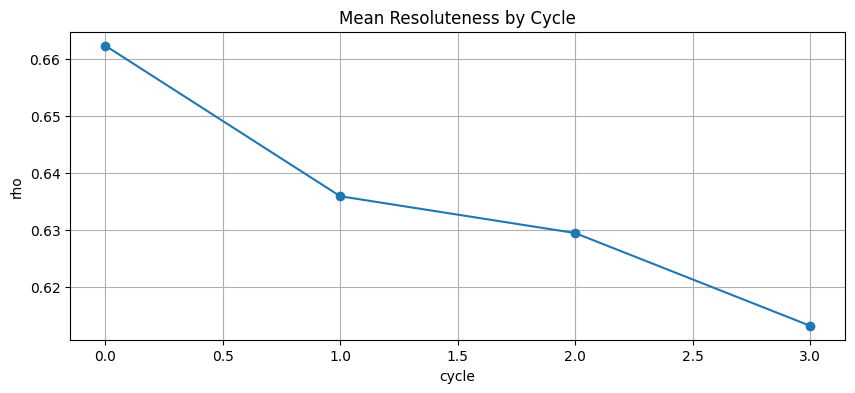

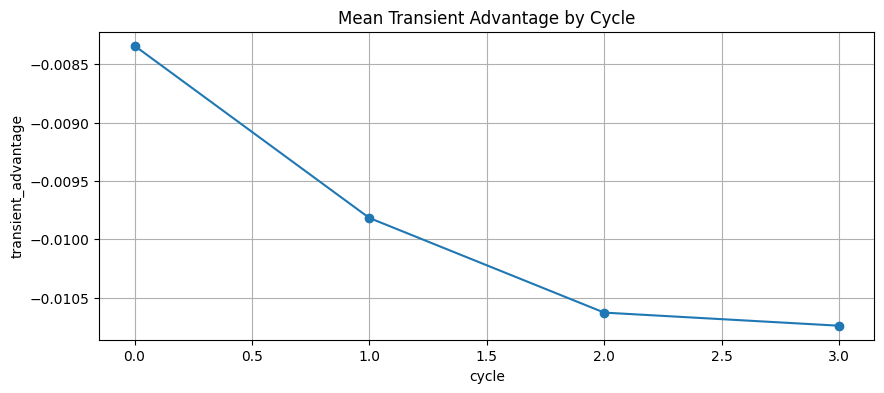

In [16]:

metrics = [
    "first_correct","v39_correct","v40_correct",
    "first_missing_mass","v39_missing_mass","v40_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()

if len(transient_trace_df):
    plt.figure(figsize=(10, 4))
    for cls in sorted(transient_trace_df["class"].unique()):
        df = transient_trace_df[transient_trace_df["class"] == cls]
        plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
    plt.title("V40 Energy by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("energy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(transient_trace_df.groupby("cycle")["rho"].mean(), marker="o")
    plt.title("Mean Resoluteness by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("rho")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(transient_trace_df.groupby("cycle")["transient_advantage"].mean(), marker="o")
    plt.title("Mean Transient Advantage by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("transient_advantage")
    plt.show()



## Practical readout

This notebook tests the continuation directly:

- fixed branches
- variable resoluteness
- branch-specific gap masks
- rival-error advantage on the same requested slice
- shared recursive matter update through the branches

Read first:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `transient_summary`
- `transient_trace_df`
